# 03 - EDA ejecutivo y KPIs de negocio

## 1. Objetivo del notebook

Este notebook busca entender el comportamiento general del marketplace a nivel de ventas, órdenes, clientes, productos, estados, medios de pago, satisfacción y logística básica.

In [1]:
## 2. Importación de librerías

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Configurar pandas para mostrar más columnas
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 1000)

In [3]:
## 3. Configuración de rutas

# Definir rutas con pathlib
ROOT_DIR = Path().absolute().parent
DATA_PROCESSED_DIR = ROOT_DIR / 'data' / 'processed'
REPORTS_DIR = ROOT_DIR / 'reports'
FIGURES_DIR = ROOT_DIR / 'reports' / 'figures'

# Crear directorios si no existen
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"ROOT_DIR: {ROOT_DIR}")
print(f"DATA_PROCESSED_DIR: {DATA_PROCESSED_DIR}")
print(f"REPORTS_DIR: {REPORTS_DIR}")
print(f"FIGURES_DIR: {FIGURES_DIR}")

ROOT_DIR: c:\Users\Samuel Vergara\Desktop\Apps\marketpulse-olist-commerce-intelligence
DATA_PROCESSED_DIR: c:\Users\Samuel Vergara\Desktop\Apps\marketpulse-olist-commerce-intelligence\data\processed
REPORTS_DIR: c:\Users\Samuel Vergara\Desktop\Apps\marketpulse-olist-commerce-intelligence\reports
FIGURES_DIR: c:\Users\Samuel Vergara\Desktop\Apps\marketpulse-olist-commerce-intelligence\reports\figures


In [4]:
## 4. Carga de datos procesados

# Validar que fact_orders exista
fact_orders_path = DATA_PROCESSED_DIR / 'fact_orders.csv'
if not fact_orders_path.exists():
    raise FileNotFoundError(
        f"El archivo {fact_orders_path} no existe. "
        "Primero debe ejecutarse notebooks/02_limpieza_etl.ipynb"
    )

# Cargar datos procesados
fact_orders = pd.read_csv(fact_orders_path)
dim_products = pd.read_csv(DATA_PROCESSED_DIR / 'dim_products.csv')
dim_customers = pd.read_csv(DATA_PROCESSED_DIR / 'dim_customers.csv')
dim_sellers = pd.read_csv(DATA_PROCESSED_DIR / 'dim_sellers.csv')

# Convertir columnas de fechas a datetime
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    if col in fact_orders.columns:
        fact_orders[col] = pd.to_datetime(fact_orders[col])

print(f"Shape de fact_orders: {fact_orders.shape}")
print(f"\nPrimeras filas de fact_orders:")
fact_orders.head()

Shape de fact_orders: (99441, 51)

Primeras filas de fact_orders:


,order_id,customer_id,customer_unique_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_zip_code_prefix,customer_city,customer_state,items_count,products_count,sellers_count,total_price,total_freight,payment_total,avg_item_price,max_item_price,min_item_price,main_category,main_payment_type,payment_count,max_installments,...,payment_types_count,review_score_avg,review_score_min,review_score_max,reviews_count,has_review_comment,bad_review,purchase_year,purchase_month,purchase_year_month,purchase_dayofweek,purchase_hour,is_delivered,is_canceled,is_unavailable,approval_time_days,carrier_handling_time_days,delivery_time_days,estimated_delivery_time_days,delivery_delay_days,is_late,freight_ratio,average_ticket,has_multiple_sellers,has_multiple_payment_methods
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,3149,sao paulo,SP,1.0,1.0,1.0,29.99,8.72,38.71,29.99,29.99,29.99,housewares,voucher,3.0,1.0,...,2.0,4.0,4.0,4.0,1.0,1.0,0.0,2017,10,2017-10,0,10,1,0,0,0.007431,2.366493,8.436574,15.544063,-7.107488,0.0,0.290764,38.71,0,1
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,47813,barreiras,BA,1.0,1.0,1.0,118.70,22.76,141.46,118.70,118.70,118.70,perfumery,boleto,1.0,1.0,...,1.0,4.0,4.0,4.0,1.0,1.0,0.0,2018,7,2018-07,1,20,1,0,0,1.279745,0.462882,13.782037,19.137766,-5.355729,0.0,0.191744,141.46,0,0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,75265,vianopolis,GO,1.0,1.0,1.0,159.90,19.22,179.12,159.90,159.90,159.90,auto,credit_card,1.0,3.0,...,1.0,5.0,5.0,5.0,1.0,0.0,0.0,2018,8,2018-08,2,8,1,0,0,0.011505,0.204595,9.394213,26.639711,-17.245498,0.0,0.120200,179.12,0,0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,59296,sao goncalo do amarante,RN,1.0,1.0,1.0,45.00,27.20,72.20,45.00,45.00,45.00,pet_shop,credit_card,1.0,1.0,...,1.0,5.0,5.0,5.0,1.0,1.0,0.0,2017,11,2017-11,5,19,1,0,0,0.012419,3.745833,13.208750,26.188819,-12.980069,0.0,0.604444,72.20,0,0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,9195,santo andre,SP,1.0,1.0,1.0,19.90,8.72,28.62,19.90,19.90,19.90,stationery,credit_card,1.0,1.0,...,1.0,5.0,5.0,5.0,1.0,0.0,0.0,2018,2,2018-02,1,21,1,0,0,0.042940,0.893113,2.873877,12.112049,-9.238171,0.0,0.438191,28.62,0,0


In [5]:
## 5. Validación rápida de la tabla base

# Mostrar estadísticas básicas
print(f"Número de filas: {len(fact_orders)}")
print(f"order_id únicos: {fact_orders['order_id'].nunique()}")
print(f"customer_unique_id únicos: {fact_orders['customer_unique_id'].nunique()}")

# Rango de fechas
if 'order_purchase_timestamp' in fact_orders.columns:
    print(f"\nRango de order_purchase_timestamp:")
    print(f"  Mínimo: {fact_orders['order_purchase_timestamp'].min()}")
    print(f"  Máximo: {fact_orders['order_purchase_timestamp'].max()}")

print(f"\nCantidad de columnas: {fact_orders.shape[1]}")

# Validar que exista una fila por orden
unique_orders = fact_orders['order_id'].nunique()
total_rows = len(fact_orders)
print(f"\nValidación de una fila por orden:")
print(f"  Filas totales: {total_rows}")
print(f"  order_id únicos: {unique_orders}")
print(f"  ¿Una fila por orden? {'Sí' if unique_orders == total_rows else 'No'}")

Número de filas: 99441
order_id únicos: 99441
customer_unique_id únicos: 96096

Rango de order_purchase_timestamp:
  Mínimo: 2016-09-04 21:15:19
  Máximo: 2018-10-17 17:30:18

Cantidad de columnas: 51

Validación de una fila por orden:
  Filas totales: 99441
  order_id únicos: 99441
  ¿Una fila por orden? Sí


In [6]:
## 6. KPIs ejecutivos generales

# Calcular KPIs principales
total_orders = len(fact_orders)
delivered_orders = len(fact_orders[fact_orders['order_status'] == 'delivered'])
canceled_orders = len(fact_orders[fact_orders['order_status'] == 'canceled'])
unavailable_orders = len(fact_orders[fact_orders['order_status'] == 'unavailable'])
unique_customers = fact_orders['customer_unique_id'].nunique()
total_revenue_items = fact_orders['total_price'].sum()
total_freight = fact_orders['total_freight'].sum()
total_payment_value = fact_orders['payment_total'].sum()
average_order_value = fact_orders['payment_total'].mean()
average_items_per_order = fact_orders['items_count'].mean()
average_review_score = fact_orders['review_score_avg'].mean()

# Calcular late_delivery_rate (solo para órdenes entregadas)
delivered_df = fact_orders[fact_orders['order_status'] == 'delivered']
if len(delivered_df) > 0 and 'delivery_delay_days' in delivered_df.columns:
    late_deliveries = len(delivered_df[delivered_df['delivery_delay_days'] > 0])
    late_delivery_rate = (late_deliveries / len(delivered_df)) * 100
else:
    late_delivery_rate = 0

# Calcular cancellation_rate
cancellation_rate = (canceled_orders / total_orders) * 100

# Calcular repeat_customer_rate
customer_order_counts = fact_orders['customer_unique_id'].value_counts()
repeat_customers = len(customer_order_counts[customer_order_counts > 1])
repeat_customer_rate = (repeat_customers / unique_customers) * 100

# Crear tabla de KPIs
kpi_executive_summary = pd.DataFrame({
    'KPI': [
        'total_orders',
        'delivered_orders',
        'canceled_orders',
        'unavailable_orders',
        'unique_customers',
        'total_revenue_items',
        'total_freight',
        'total_payment_value',
        'average_order_value',
        'average_items_per_order',
        'average_review_score',
        'late_delivery_rate',
        'cancellation_rate',
        'repeat_customer_rate'
    ],
    'Valor': [
        total_orders,
        delivered_orders,
        canceled_orders,
        unavailable_orders,
        unique_customers,
        total_revenue_items,
        total_freight,
        total_payment_value,
        average_order_value,
        average_items_per_order,
        average_review_score,
        late_delivery_rate,
        cancellation_rate,
        repeat_customer_rate
    ]
})

print("KPIs Ejecutivos Generales:")
print(kpi_executive_summary.to_string(index=False))

# Guardar tabla
kpi_executive_summary.to_csv(REPORTS_DIR / 'kpi_executive_summary.csv', index=False)

KPIs Ejecutivos Generales:
                    KPI        Valor
           total_orders 9.944100e+04
       delivered_orders 9.647800e+04
        canceled_orders 6.250000e+02
     unavailable_orders 6.090000e+02
       unique_customers 9.609600e+04
    total_revenue_items 1.359164e+07
          total_freight 2.251910e+06
    total_payment_value 1.600887e+07
    average_order_value 1.609903e+02
average_items_per_order 1.141731e+00
   average_review_score 4.086793e+00
     late_delivery_rate 8.111694e+00
      cancellation_rate 6.285134e-01
   repeat_customer_rate 3.118756e+00


Órdenes por estado:
order_status  count  percentage
   delivered  96478   97.020344
     shipped   1107    1.113223
    canceled    625    0.628513
 unavailable    609    0.612423
    invoiced    314    0.315765
  processing    301    0.302692
     created      5    0.005028
    approved      2    0.002011


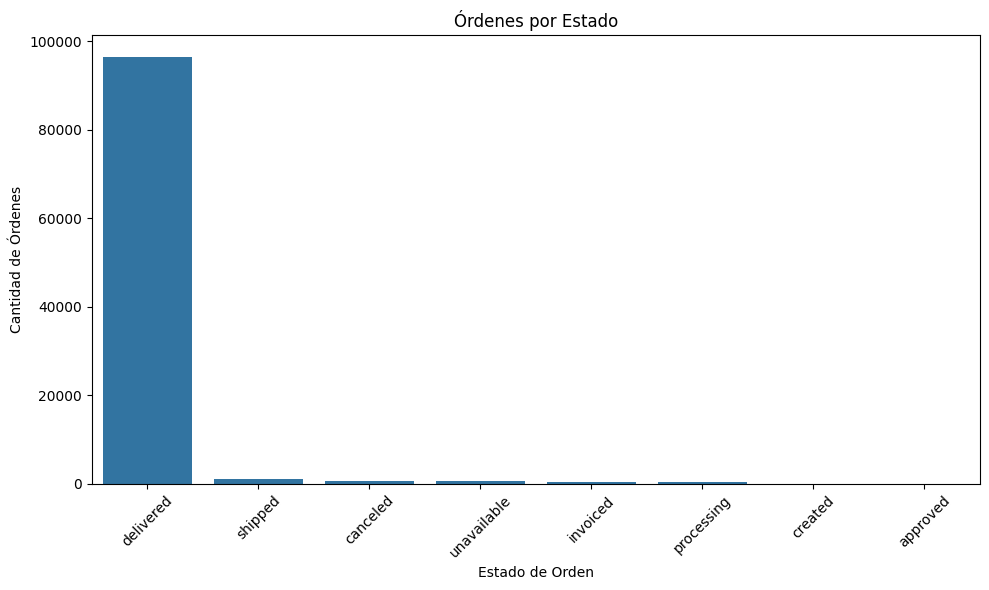

In [7]:
## 7. Análisis de estados de orden

# Crear tabla con conteo y porcentaje por order_status
orders_by_status = fact_orders['order_status'].value_counts().reset_index()
orders_by_status.columns = ['order_status', 'count']
orders_by_status['percentage'] = (orders_by_status['count'] / orders_by_status['count'].sum()) * 100

print("Órdenes por estado:")
print(orders_by_status.to_string(index=False))

# Visualizar gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(data=orders_by_status, x='order_status', y='count')
plt.title('Órdenes por Estado')
plt.xlabel('Estado de Orden')
plt.ylabel('Cantidad de Órdenes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'orders_by_status.png')
plt.show()

# Guardar tabla
orders_by_status.to_csv(REPORTS_DIR / 'orders_by_status.csv', index=False)

Métricas mensuales:
  month  orders  revenue_items  payment_value  freight_value  unique_customers  average_review_score  average_order_value  late_delivery_rate
2016-09       4         267.36         252.24          87.39                 4              1.000000            63.060000          100.000000
2016-10     324       49507.66       59090.48        7301.18               321              3.561129           182.378025            1.132075
2016-12       1          10.90          19.62           8.72                 1              5.000000            19.620000            0.000000
2017-01     800      120312.87      138488.04       16875.62               765              4.062658           173.110050            3.066667
2017-02    1780      247303.02      291908.01       38977.60              1755              4.015837           163.993264            3.206292
2017-03    2682      374344.30      449863.60       57704.29              2642              4.074596           167.734377       

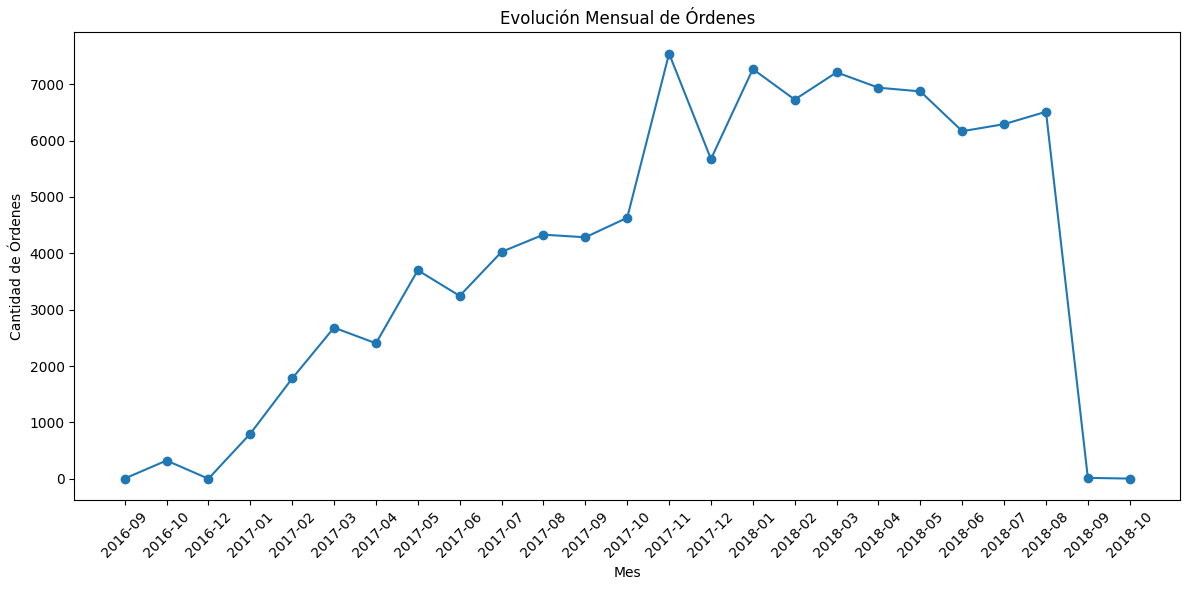

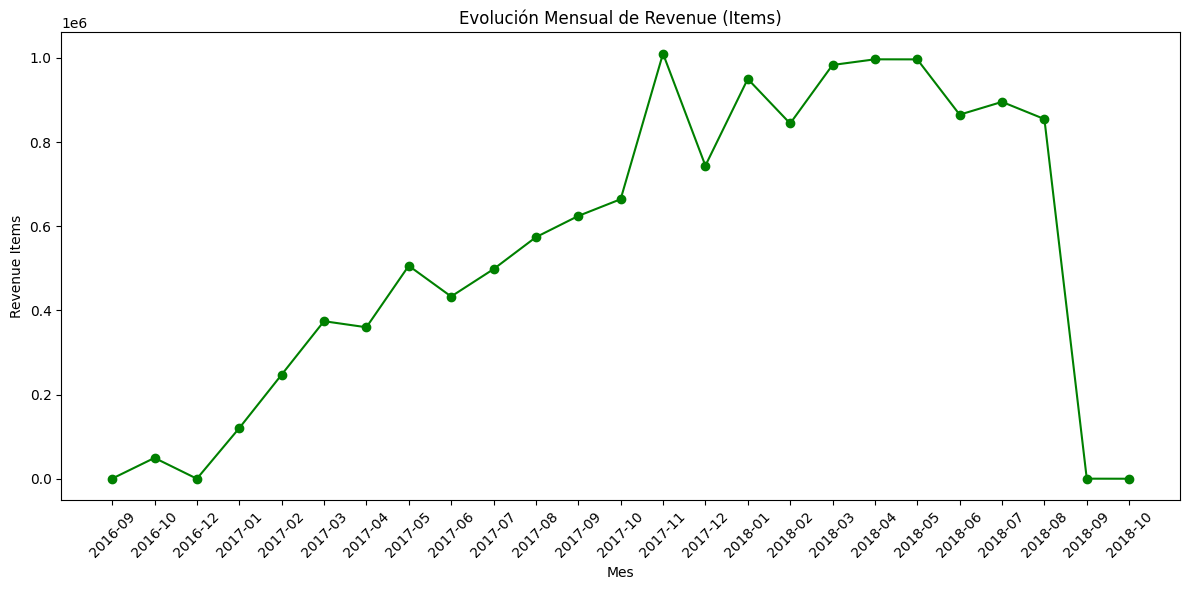

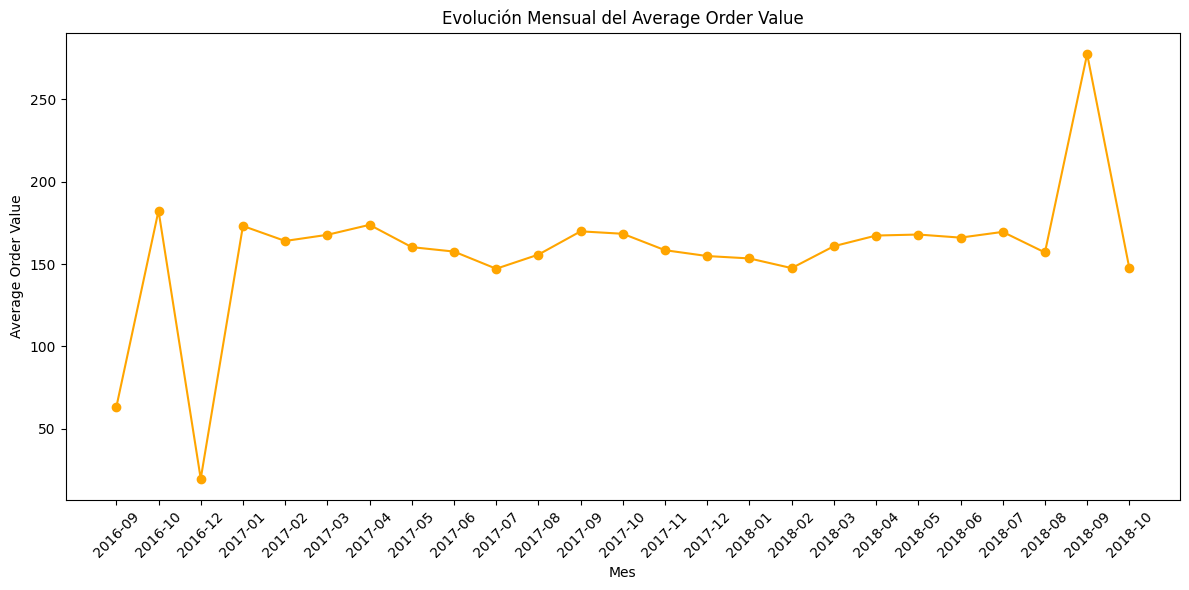

In [9]:
## 8. Evolución temporal de ventas y órdenes

# Crear tabla mensual usando purchase_year_month
monthly_metrics = fact_orders.groupby('purchase_year_month').agg({
    'order_id': 'nunique',
    'total_price': 'sum',
    'payment_total': 'sum',
    'total_freight': 'sum',
    'customer_unique_id': 'nunique',
    'review_score_avg': 'mean'
}).reset_index()

monthly_metrics.columns = [
    'month',
    'orders',
    'revenue_items',
    'payment_value',
    'freight_value',
    'unique_customers',
    'average_review_score'
]

# Calcular average_order_value por mes
monthly_metrics['average_order_value'] = monthly_metrics['payment_value'] / monthly_metrics['orders']

# Calcular late_delivery_rate por mes
delivered_by_month = fact_orders[fact_orders['order_status'] == 'delivered'].groupby('purchase_year_month').apply(
    lambda x: (x['delivery_delay_days'] > 0).sum() / len(x) * 100
).reset_index()
delivered_by_month.columns = ['month', 'late_delivery_rate']
monthly_metrics = monthly_metrics.merge(delivered_by_month, on='month', how='left')

print("Métricas mensuales:")
print(monthly_metrics.to_string(index=False))

# Visualizar línea de órdenes mensuales
plt.figure(figsize=(12, 6))
plt.plot(monthly_metrics['month'], monthly_metrics['orders'], marker='o')
plt.title('Evolución Mensual de Órdenes')
plt.xlabel('Mes')
plt.ylabel('Cantidad de Órdenes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'monthly_orders.png')
plt.show()

# Visualizar línea de revenue_items mensual
plt.figure(figsize=(12, 6))
plt.plot(monthly_metrics['month'], monthly_metrics['revenue_items'], marker='o', color='green')
plt.title('Evolución Mensual de Revenue (Items)')
plt.xlabel('Mes')
plt.ylabel('Revenue Items')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'monthly_revenue.png')
plt.show()

# Visualizar línea de average_order_value mensual
plt.figure(figsize=(12, 6))
plt.plot(monthly_metrics['month'], monthly_metrics['average_order_value'], marker='o', color='orange')
plt.title('Evolución Mensual del Average Order Value')
plt.xlabel('Mes')
plt.ylabel('Average Order Value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'monthly_aov.png')
plt.show()

# Guardar tabla
monthly_metrics.to_csv(REPORTS_DIR / 'monthly_business_metrics.csv', index=False)

Distribución de frecuencia de órdenes por cliente:
  Clientes con 1 orden: 93099 (96.88%)
  Clientes con 2 órdenes: 2745 (2.86%)
  Clientes con 3 o más órdenes: 252 (0.26%)
  Porcentaje de clientes recurrentes: 3.12%


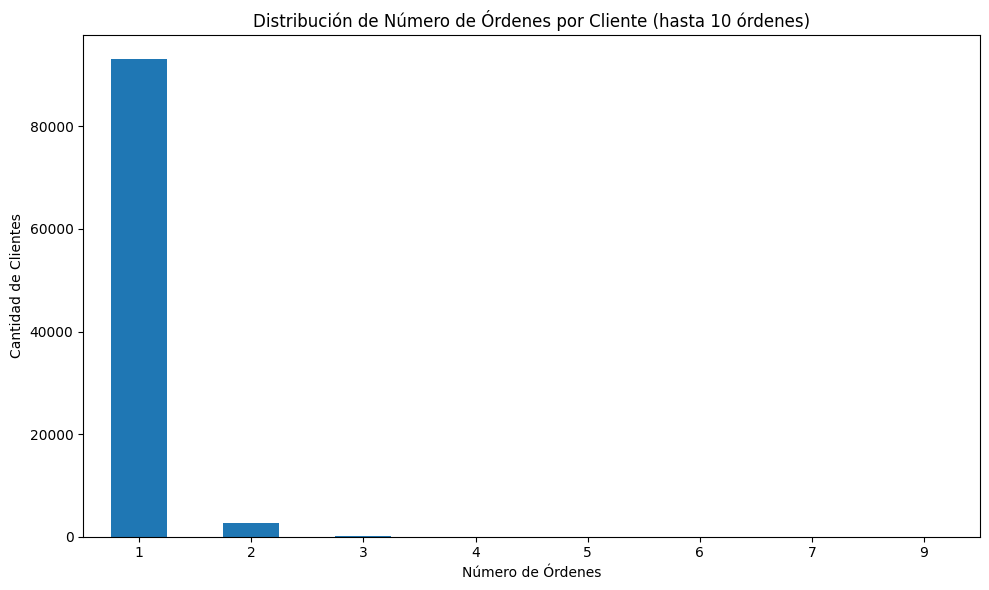

In [10]:
## 9. Análisis de clientes

# Crear tabla de frecuencia de órdenes por customer_unique_id
customer_order_counts = fact_orders['customer_unique_id'].value_counts().reset_index()
customer_order_counts.columns = ['customer_unique_id', 'order_count']

# Calcular distribuciones
customers_1_order = len(customer_order_counts[customer_order_counts['order_count'] == 1])
customers_2_orders = len(customer_order_counts[customer_order_counts['order_count'] == 2])
customers_3plus_orders = len(customer_order_counts[customer_order_counts['order_count'] >= 3])
total_customers = len(customer_order_counts)
repeat_customer_rate_calc = (customers_2_orders + customers_3plus_orders) / total_customers * 100

print("Distribución de frecuencia de órdenes por cliente:")
print(f"  Clientes con 1 orden: {customers_1_order} ({customers_1_order/total_customers*100:.2f}%)")
print(f"  Clientes con 2 órdenes: {customers_2_orders} ({customers_2_orders/total_customers*100:.2f}%)")
print(f"  Clientes con 3 o más órdenes: {customers_3plus_orders} ({customers_3plus_orders/total_customers*100:.2f}%)")
print(f"  Porcentaje de clientes recurrentes: {repeat_customer_rate_calc:.2f}%")

# Visualizar distribución limitada a clientes con hasta 10 órdenes
customer_order_dist = customer_order_counts[customer_order_counts['order_count'] <= 10]['order_count'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
customer_order_dist.plot(kind='bar')
plt.title('Distribución de Número de Órdenes por Cliente (hasta 10 órdenes)')
plt.xlabel('Número de Órdenes')
plt.ylabel('Cantidad de Clientes')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'customer_order_distribution.png')
plt.show()

# Guardar tabla
customer_order_counts.to_csv(REPORTS_DIR / 'customer_order_frequency.csv', index=False)

Métricas por estado (top 15):
customer_state  orders  unique_customers  revenue_items  payment_value  average_review_score  average_order_value  late_delivery_rate
            SP   41746             40302     5202955.05     5998226.96              4.174126           143.683873            5.893682
            RJ   12852             12384     1824092.67     2144379.69              3.877263           166.851828           13.473684
            MG   11635             11259     1585308.03     1872257.26              4.135754           160.915966            5.610358
            RS    5466              5277      750304.02      890898.54              4.133658           162.989122            7.146866
            PR    5045              4882      683083.76      811156.38              4.181112           160.784218            4.996953
            SC    3637              3534      520553.34      623086.43              4.073705           171.318787            9.757473
            BA    3380          

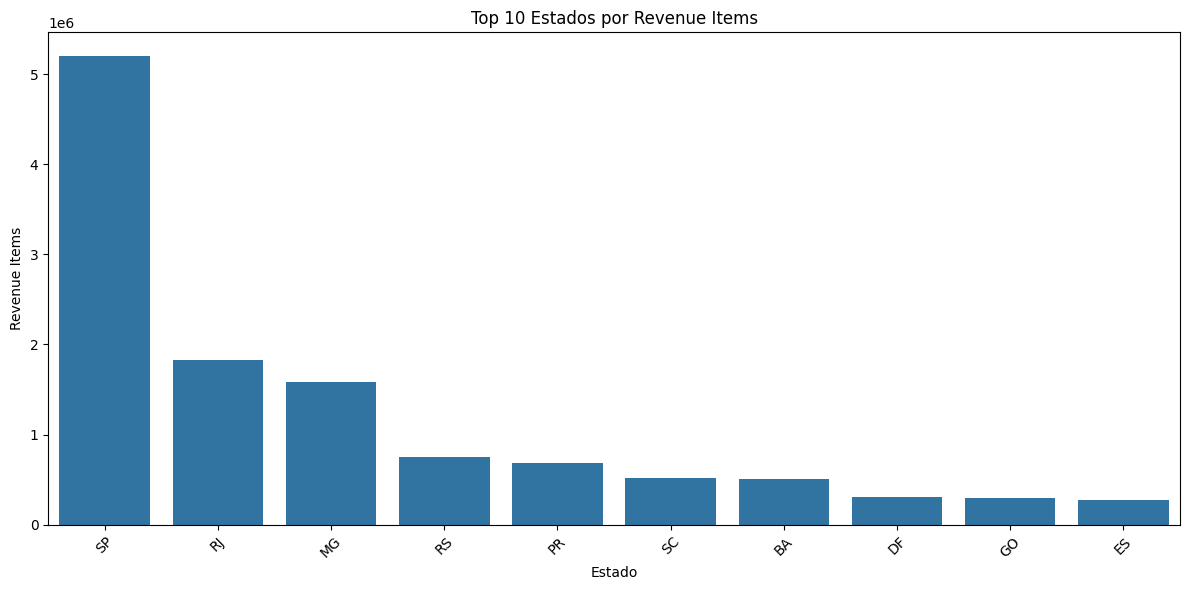

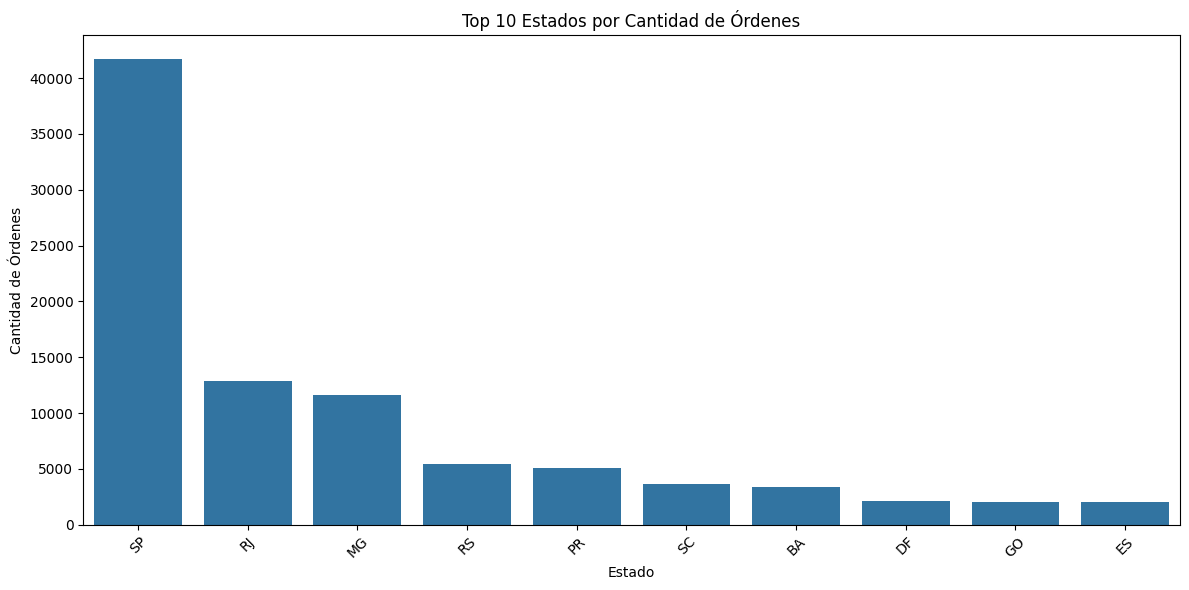

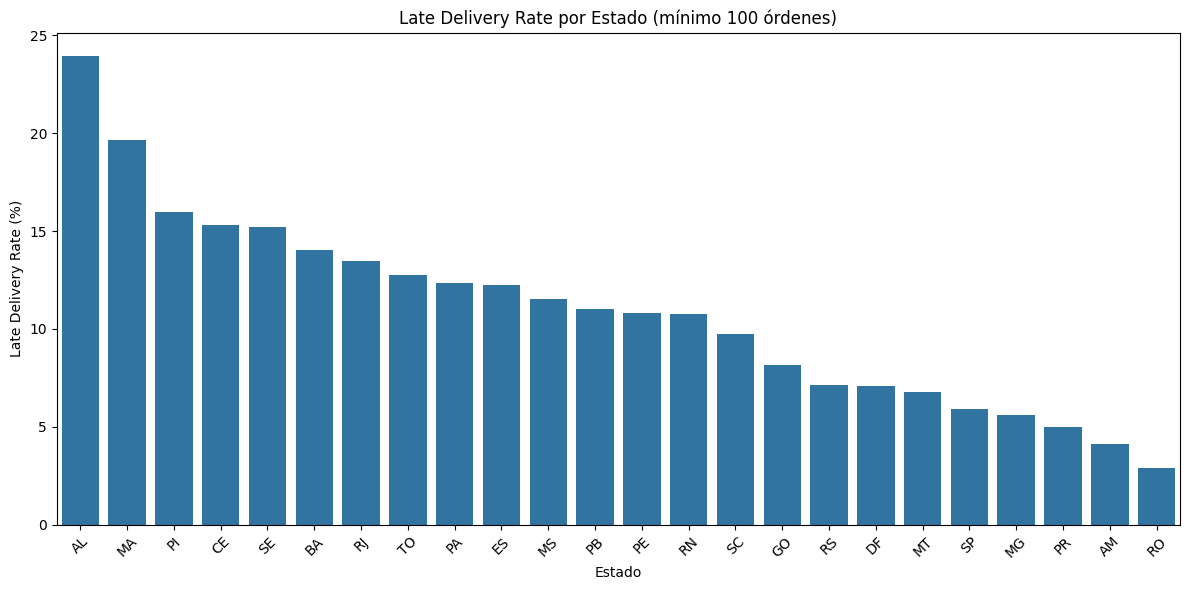

In [11]:
## 10. Análisis por estado del cliente

# Agrupar por customer_state
state_metrics = fact_orders.groupby('customer_state').agg({
    'order_id': 'nunique',
    'customer_unique_id': 'nunique',
    'total_price': 'sum',
    'payment_total': 'sum',
    'review_score_avg': 'mean'
}).reset_index()

state_metrics.columns = [
    'customer_state',
    'orders',
    'unique_customers',
    'revenue_items',
    'payment_value',
    'average_review_score'
]

# Calcular average_order_value
state_metrics['average_order_value'] = state_metrics['payment_value'] / state_metrics['orders']

# Calcular late_delivery_rate por estado (solo estados con mínimo 100 órdenes)
delivered_by_state = fact_orders[fact_orders['order_status'] == 'delivered'].groupby('customer_state').apply(
    lambda x: (x['delivery_delay_days'] > 0).sum() / len(x) * 100 if len(x) > 0 else 0
).reset_index()
delivered_by_state.columns = ['customer_state', 'late_delivery_rate']
state_metrics = state_metrics.merge(delivered_by_state, on='customer_state', how='left')

# Ordenar por revenue_items descendente
state_metrics = state_metrics.sort_values('revenue_items', ascending=False)

print("Métricas por estado (top 15):")
print(state_metrics.head(15).to_string(index=False))

# Visualizar top 10 estados por revenue_items
plt.figure(figsize=(12, 6))
sns.barplot(data=state_metrics.head(10), x='customer_state', y='revenue_items')
plt.title('Top 10 Estados por Revenue Items')
plt.xlabel('Estado')
plt.ylabel('Revenue Items')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'top_states_revenue.png')
plt.show()

# Visualizar top 10 estados por cantidad de órdenes
plt.figure(figsize=(12, 6))
sns.barplot(data=state_metrics.head(10), x='customer_state', y='orders')
plt.title('Top 10 Estados por Cantidad de Órdenes')
plt.xlabel('Estado')
plt.ylabel('Cantidad de Órdenes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'top_states_orders.png')
plt.show()

# Visualizar late_delivery_rate por estado (mínimo 100 órdenes)
states_with_100_orders = state_metrics[state_metrics['orders'] >= 100].sort_values('late_delivery_rate', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=states_with_100_orders, x='customer_state', y='late_delivery_rate')
plt.title('Late Delivery Rate por Estado (mínimo 100 órdenes)')
plt.xlabel('Estado')
plt.ylabel('Late Delivery Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'late_delivery_by_state.png')
plt.show()

# Guardar tabla
state_metrics.to_csv(REPORTS_DIR / 'state_business_metrics.csv', index=False)

Métricas por categoría (top 15):
        main_category  orders  revenue_items  payment_value  average_review_score  average_order_value  late_delivery_rate
        health_beauty    8810     1260402.23     1443182.68              4.183800           163.811882            8.978077
        watches_gifts    5584     1199042.79     1299139.04              4.073325           232.653840            8.579285
       bed_bath_table    9384     1049531.99     1257709.90              3.974677           134.027057            8.778006
       sports_leisure    7668      985965.36     1154092.27              4.177104           150.507599            7.782830
computers_accessories    6679      915673.93     1063925.67              4.027188           159.294156            7.714724
      furniture_decor    6350      733437.63      907045.66              4.023730           142.841836            8.569588
           cool_stuff    3589      632552.76      716406.30              4.186164           199.611675    

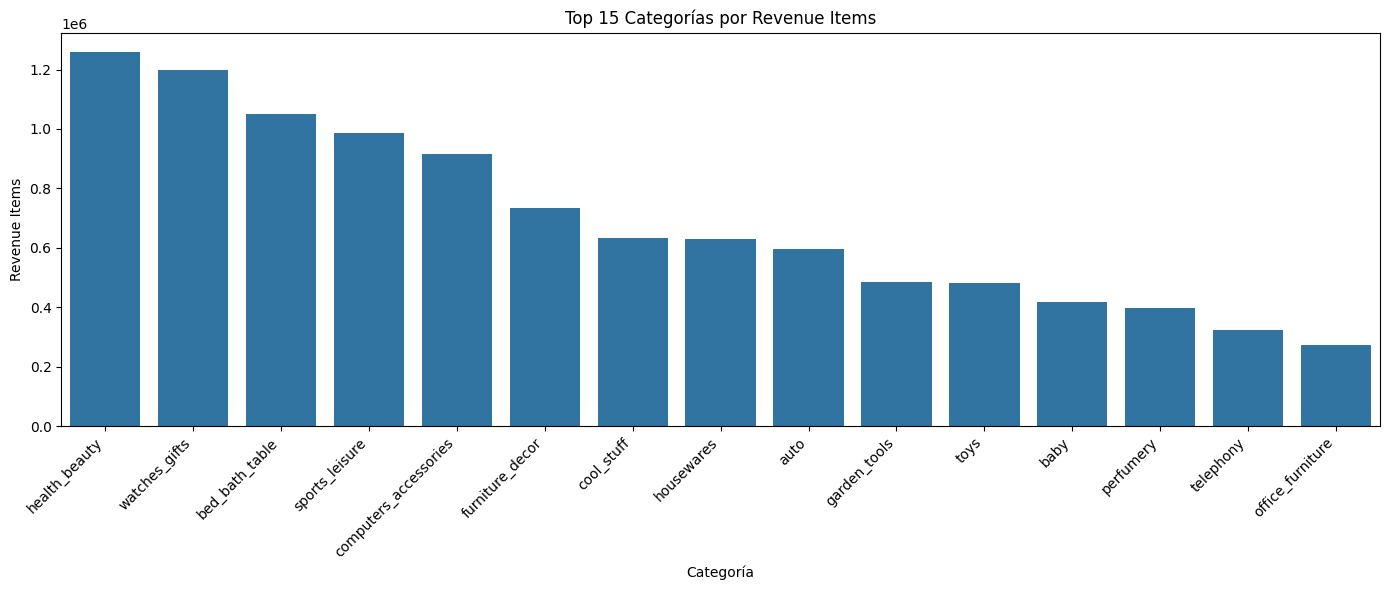

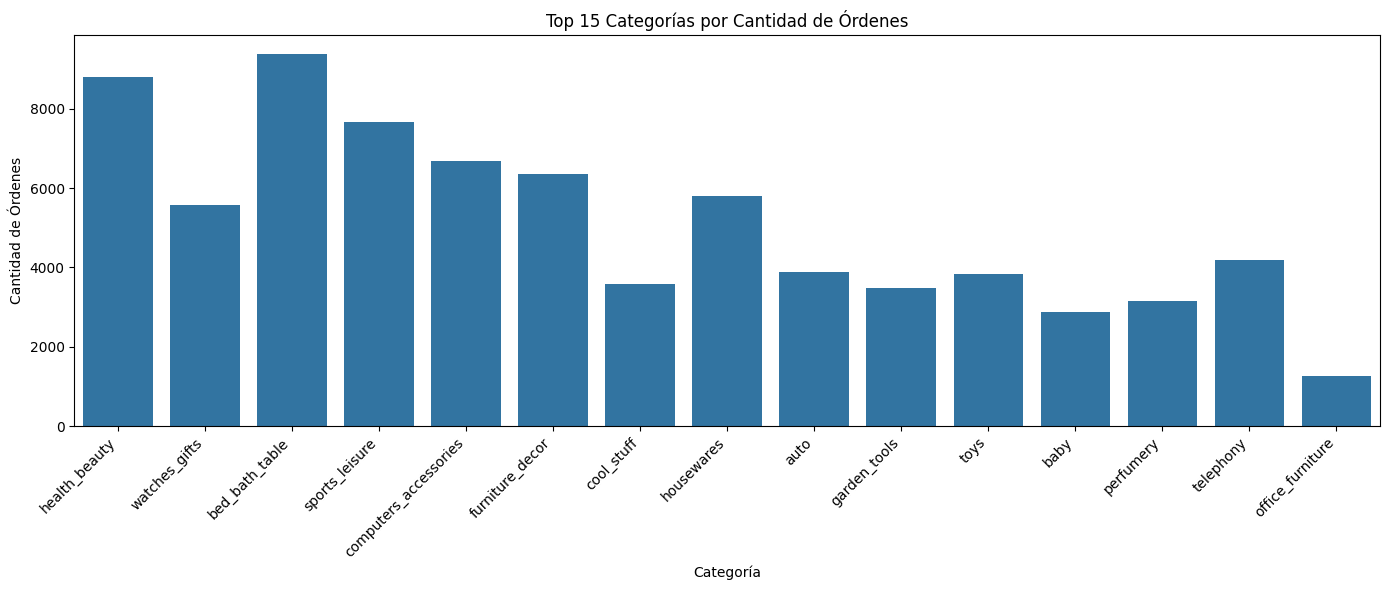

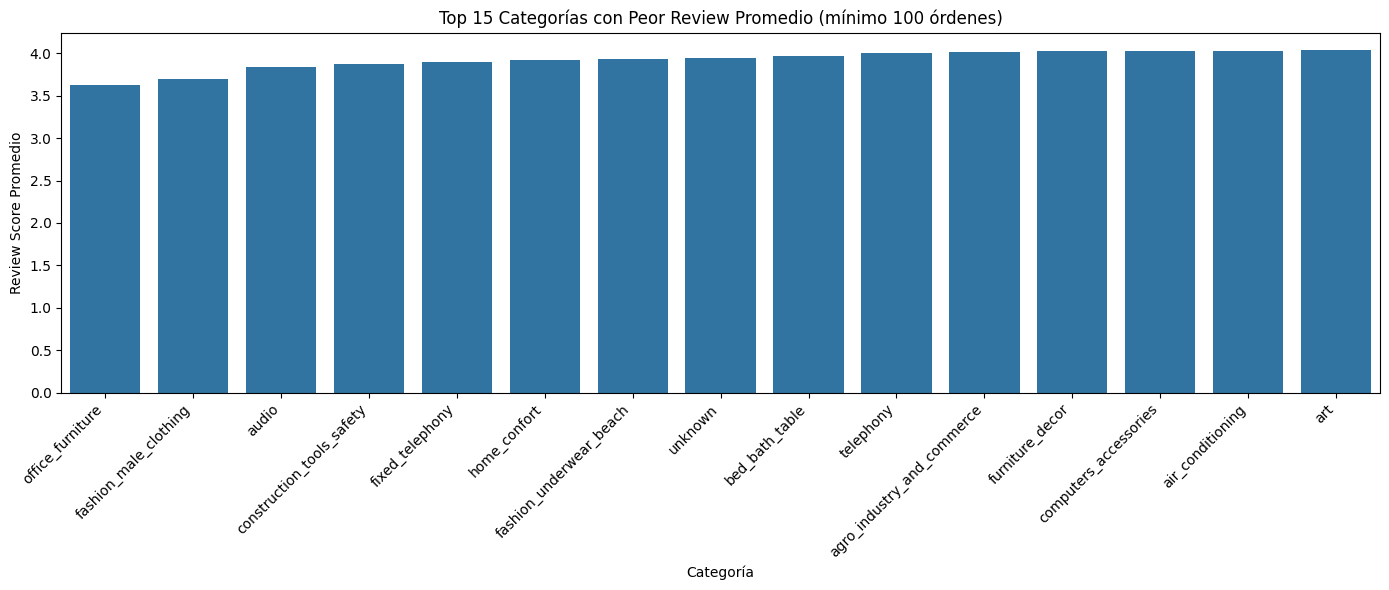

In [12]:
## 11. Análisis de categorías de producto

# Agrupar por main_category
category_metrics = fact_orders.groupby('main_category').agg({
    'order_id': 'nunique',
    'total_price': 'sum',
    'payment_total': 'sum',
    'review_score_avg': 'mean'
}).reset_index()

category_metrics.columns = [
    'main_category',
    'orders',
    'revenue_items',
    'payment_value',
    'average_review_score'
]

# Calcular average_order_value
category_metrics['average_order_value'] = category_metrics['payment_value'] / category_metrics['orders']

# Calcular late_delivery_rate por categoría (solo categorías con datos)
delivered_by_category = fact_orders[fact_orders['order_status'] == 'delivered'].groupby('main_category').apply(
    lambda x: (x['delivery_delay_days'] > 0).sum() / len(x) * 100 if len(x) > 0 else 0
).reset_index()
delivered_by_category.columns = ['main_category', 'late_delivery_rate']
category_metrics = category_metrics.merge(delivered_by_category, on='main_category', how='left')

# Ordenar por revenue_items descendente
category_metrics = category_metrics.sort_values('revenue_items', ascending=False)

print("Métricas por categoría (top 15):")
print(category_metrics.head(15).to_string(index=False))

# Visualizar top 15 categorías por revenue_items
plt.figure(figsize=(14, 6))
sns.barplot(data=category_metrics.head(15), x='main_category', y='revenue_items')
plt.title('Top 15 Categorías por Revenue Items')
plt.xlabel('Categoría')
plt.ylabel('Revenue Items')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'top_categories_revenue.png')
plt.show()

# Visualizar top 15 categorías por órdenes
plt.figure(figsize=(14, 6))
sns.barplot(data=category_metrics.head(15), x='main_category', y='orders')
plt.title('Top 15 Categorías por Cantidad de Órdenes')
plt.xlabel('Categoría')
plt.ylabel('Cantidad de Órdenes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'top_categories_orders.png')
plt.show()

# Visualizar categorías con peor review promedio (mínimo 100 órdenes)
categories_100_orders = category_metrics[category_metrics['orders'] >= 100].sort_values('average_review_score', ascending=True)

plt.figure(figsize=(14, 6))
sns.barplot(data=categories_100_orders.head(15), x='main_category', y='average_review_score')
plt.title('Top 15 Categorías con Peor Review Promedio (mínimo 100 órdenes)')
plt.xlabel('Categoría')
plt.ylabel('Review Score Promedio')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'worst_review_categories.png')
plt.show()

# Guardar tabla
category_metrics.to_csv(REPORTS_DIR / 'category_business_metrics.csv', index=False)

Métricas por tipo de pago:
main_payment_type  orders  payment_value  avg_installments  average_review_score  average_order_value
           boleto   19784     2869361.27          1.000000              4.087136           145.034435
      credit_card   74975    12542527.15          3.554398              4.088537           167.289458
       debit_card    1527      217939.79          1.000000              4.169954           142.724158
      not_defined       3           0.00          1.000000              1.666667             0.000000
          voucher    3151      379043.91          1.144399              4.005874           120.293212


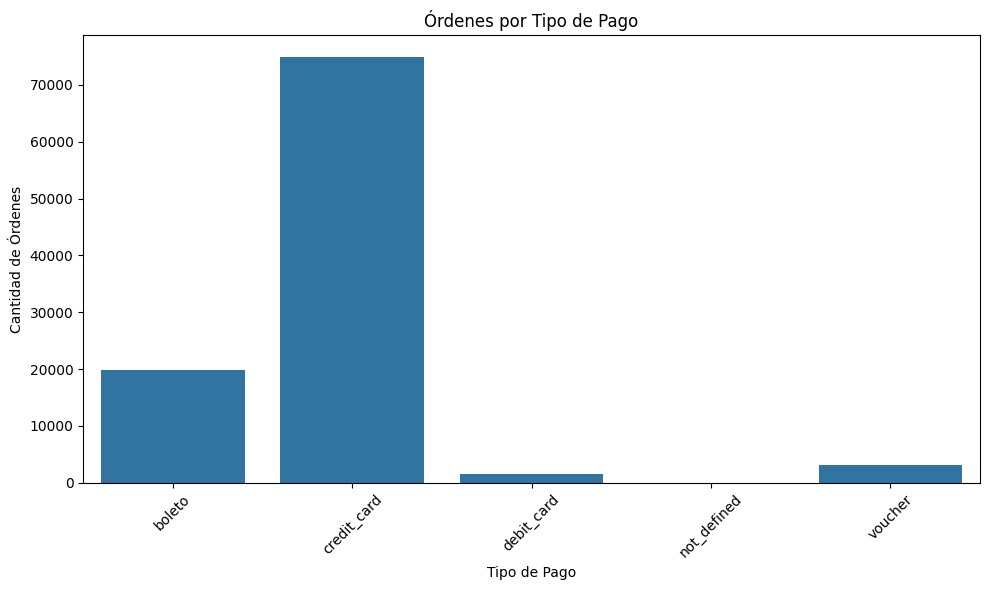

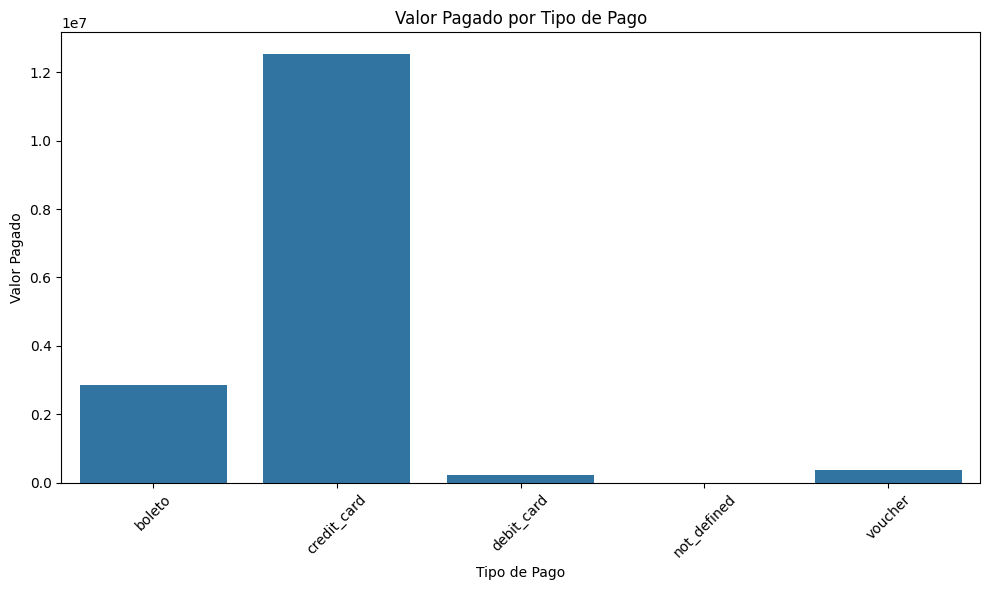

In [14]:
## 12. Análisis de medios de pago

# Agrupar por main_payment_type
payment_metrics = fact_orders.groupby('main_payment_type').agg({
    'order_id': 'nunique',
    'payment_total': 'sum',
    'max_installments': 'mean',
    'review_score_avg': 'mean'
}).reset_index()

payment_metrics.columns = [
    'main_payment_type',
    'orders',
    'payment_value',
    'avg_installments',
    'average_review_score'
]

# Calcular average_order_value
payment_metrics['average_order_value'] = payment_metrics['payment_value'] / payment_metrics['orders']

print("Métricas por tipo de pago:")
print(payment_metrics.to_string(index=False))

# Visualizar órdenes por tipo de pago
plt.figure(figsize=(10, 6))
sns.barplot(data=payment_metrics, x='main_payment_type', y='orders')
plt.title('Órdenes por Tipo de Pago')
plt.xlabel('Tipo de Pago')
plt.ylabel('Cantidad de Órdenes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'orders_by_payment_type.png')
plt.show()

# Visualizar valor pagado por tipo de pago
plt.figure(figsize=(10, 6))
sns.barplot(data=payment_metrics, x='main_payment_type', y='payment_value')
plt.title('Valor Pagado por Tipo de Pago')
plt.xlabel('Tipo de Pago')
plt.ylabel('Valor Pagado')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'payment_value_by_type.png')
plt.show()

# Guardar tabla
payment_metrics.to_csv(REPORTS_DIR / 'payment_type_metrics.csv', index=False)

Estadísticas logísticas básicas:
                     métrica   promedio    mediana      mínimo     máximo  percentil_25  percentil_75
          approval_time_days   0.428199   0.014306    0.000000  30.893484      0.008970      0.604774
  carrier_handling_time_days   2.799076   1.815845 -171.219005 125.762569      0.874363      3.575009
          delivery_time_days  12.558217  10.217477    0.533414 209.628611      6.766204     15.720182
estimated_delivery_time_days  23.736347  23.230880    2.008009 155.135463     18.330081     28.407590
         delivery_delay_days -11.178126 -11.948102 -146.016123 188.975081    -16.244065     -6.389815


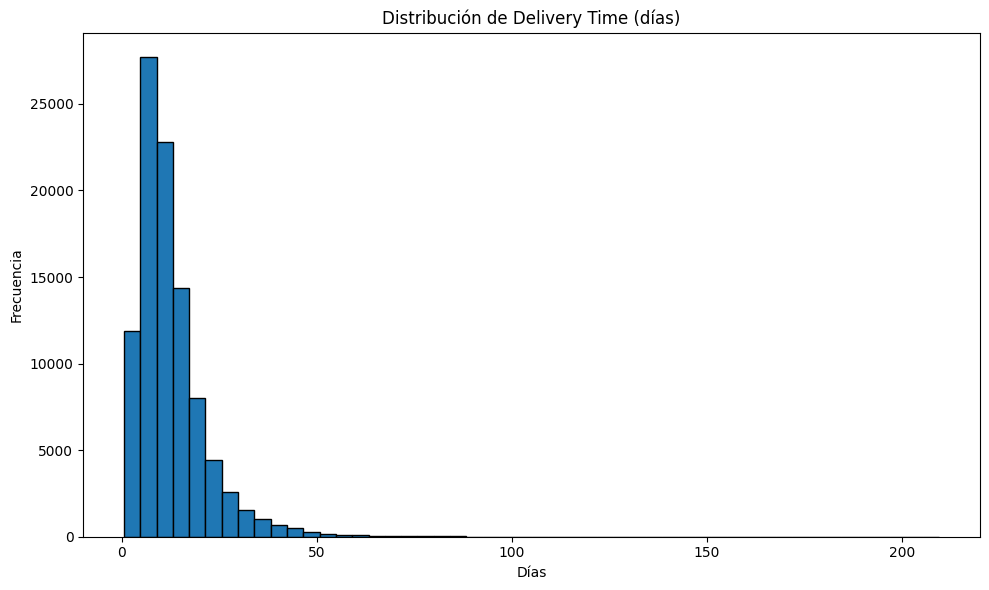

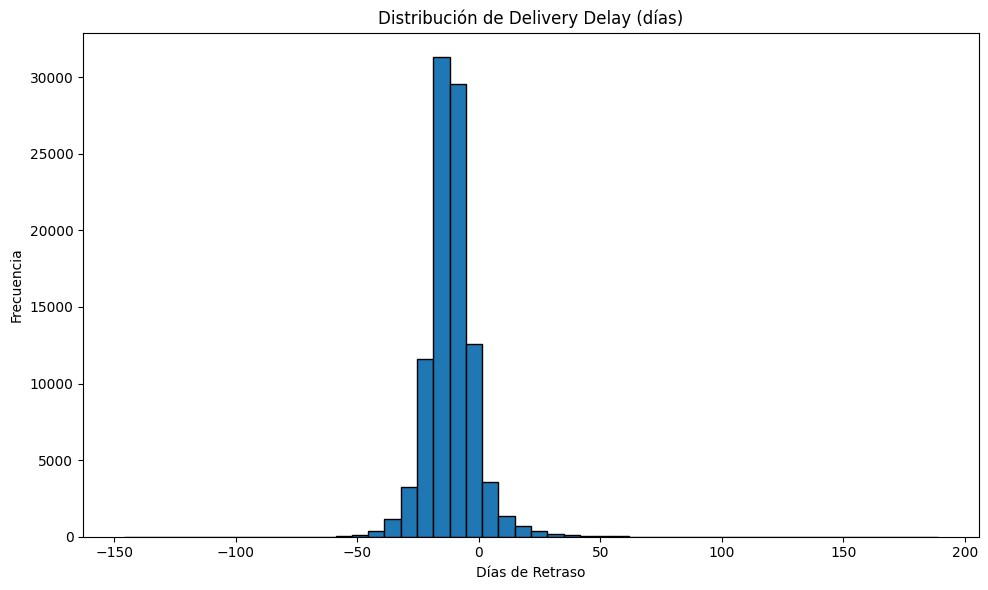

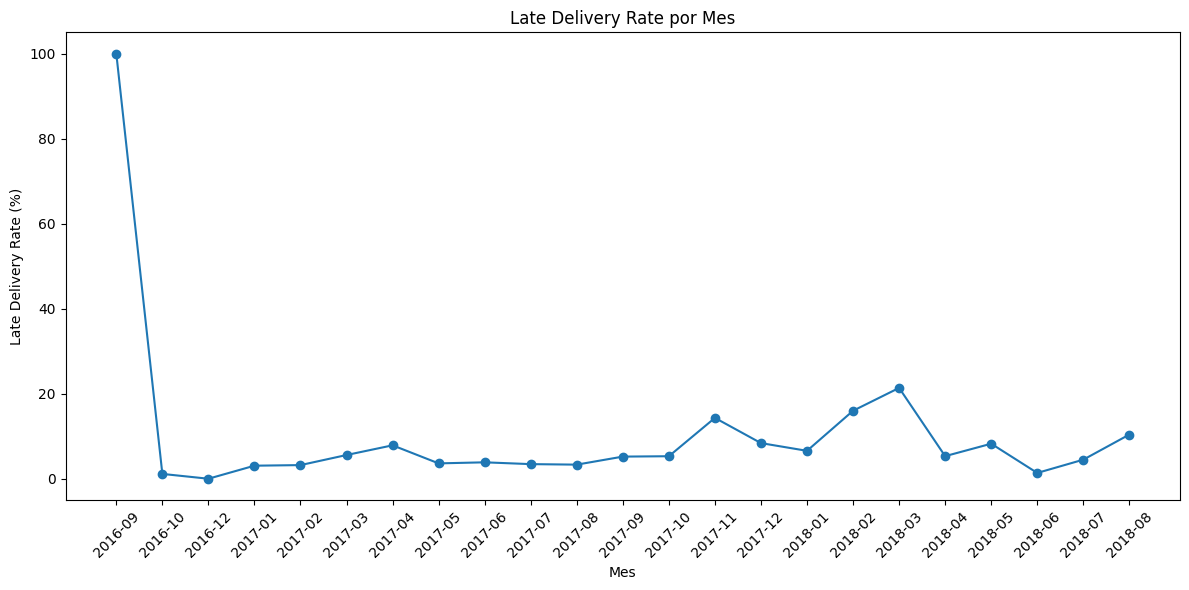

In [15]:
## 13. Análisis logístico básico

# Usar solo órdenes entregadas cuando aplique
delivered_df = fact_orders[fact_orders['order_status'] == 'delivered'].copy()

# Calcular estadísticas de tiempos logísticos
logistics_columns = [
    'approval_time_days',
    'carrier_handling_time_days',
    'delivery_time_days',
    'estimated_delivery_time_days',
    'delivery_delay_days'
]

logistics_stats = []
for col in logistics_columns:
    if col in delivered_df.columns:
        stats = {
            'métrica': col,
            'promedio': delivered_df[col].mean(),
            'mediana': delivered_df[col].median(),
            'mínimo': delivered_df[col].min(),
            'máximo': delivered_df[col].max(),
            'percentil_25': delivered_df[col].quantile(0.25),
            'percentil_75': delivered_df[col].quantile(0.75)
        }
        logistics_stats.append(stats)

logistics_summary = pd.DataFrame(logistics_stats)

print("Estadísticas logísticas básicas:")
print(logistics_summary.to_string(index=False))

# Visualizar distribución de delivery_time_days
if 'delivery_time_days' in delivered_df.columns:
    plt.figure(figsize=(10, 6))
    plt.hist(delivered_df['delivery_time_days'], bins=50, edgecolor='black')
    plt.title('Distribución de Delivery Time (días)')
    plt.xlabel('Días')
    plt.ylabel('Frecuencia')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'delivery_time_distribution.png')
    plt.show()

# Visualizar distribución de delivery_delay_days
if 'delivery_delay_days' in delivered_df.columns:
    plt.figure(figsize=(10, 6))
    plt.hist(delivered_df['delivery_delay_days'], bins=50, edgecolor='black')
    plt.title('Distribución de Delivery Delay (días)')
    plt.xlabel('Días de Retraso')
    plt.ylabel('Frecuencia')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'delivery_delay_distribution.png')
    plt.show()

# Visualizar late_delivery_rate por mes
late_delivery_by_month = fact_orders[fact_orders['order_status'] == 'delivered'].groupby('purchase_year_month').apply(
    lambda x: (x['delivery_delay_days'] > 0).sum() / len(x) * 100
).reset_index()
late_delivery_by_month.columns = ['month', 'late_delivery_rate']

plt.figure(figsize=(12, 6))
plt.plot(late_delivery_by_month['month'], late_delivery_by_month['late_delivery_rate'], marker='o')
plt.title('Late Delivery Rate por Mes')
plt.xlabel('Mes')
plt.ylabel('Late Delivery Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'late_delivery_monthly.png')
plt.show()

# Guardar tabla
logistics_summary.to_csv(REPORTS_DIR / 'logistics_basic_metrics.csv', index=False)

Distribución de review_score (redondeado):
review_score_rounded
1.0    11316
2.0     3167
3.0     8137
4.0    19098
5.0    56955
Name: count, dtype: int64


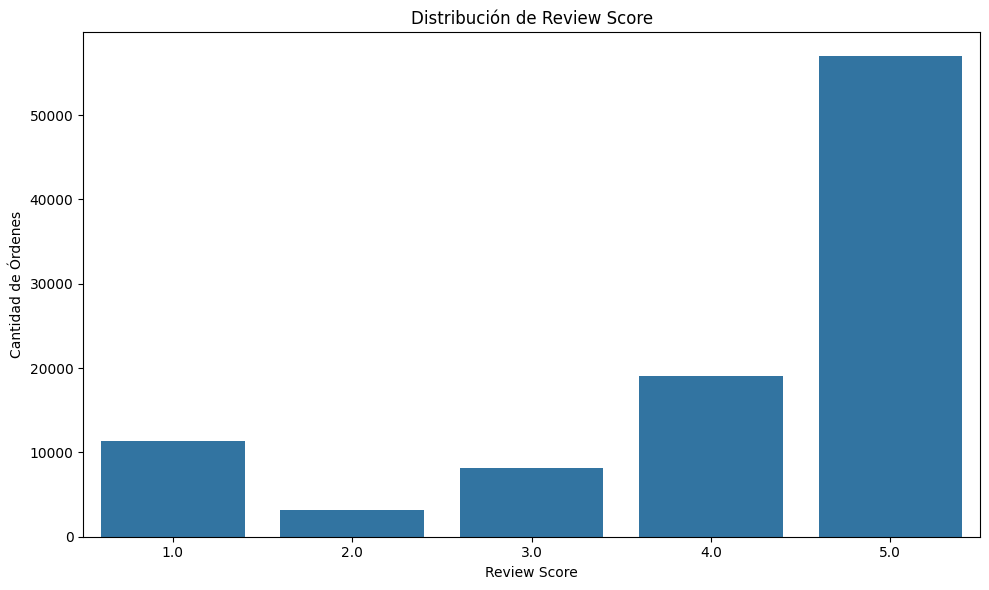

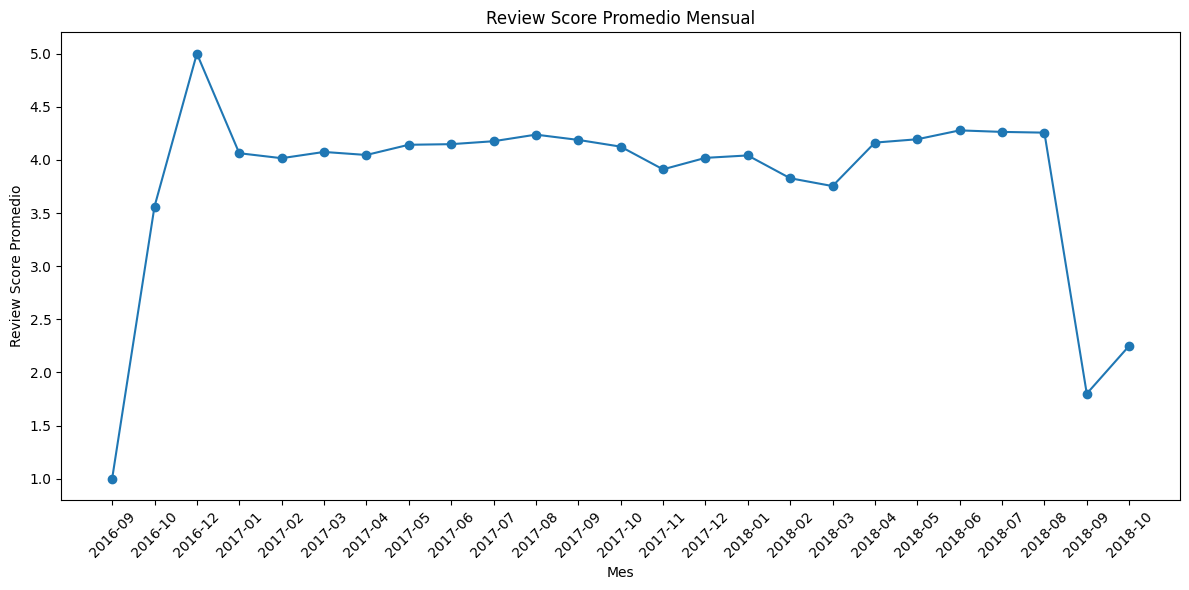


Review Score Promedio por Estado de Orden:
order_status  review_score_avg
    approved          2.500000
    canceled          1.800000
     created          2.333333
   delivered          4.156187
    invoiced          1.642395
  processing          1.271186
     shipped          2.002422
 unavailable          1.530252

Bad Review Rate General: 14.56%

Top 15 Categorías con Mayor Tasa de Mala Reseña (mínimo 100 órdenes):
            main_category  bad_review_rate  orders
    fashion_male_clothing        25.892857     112
         office_furniture        22.327791    1263
                    audio        21.714286     350
construction_tools_safety        19.631902     163
                  unknown        18.592965    1393
          fixed_telephony        18.433180     217
  fashion_underwear_beach        18.181818     121
             home_confort        17.948718     351
           bed_bath_table        16.464194    9384
         air_conditioning        16.205534     253
          fu

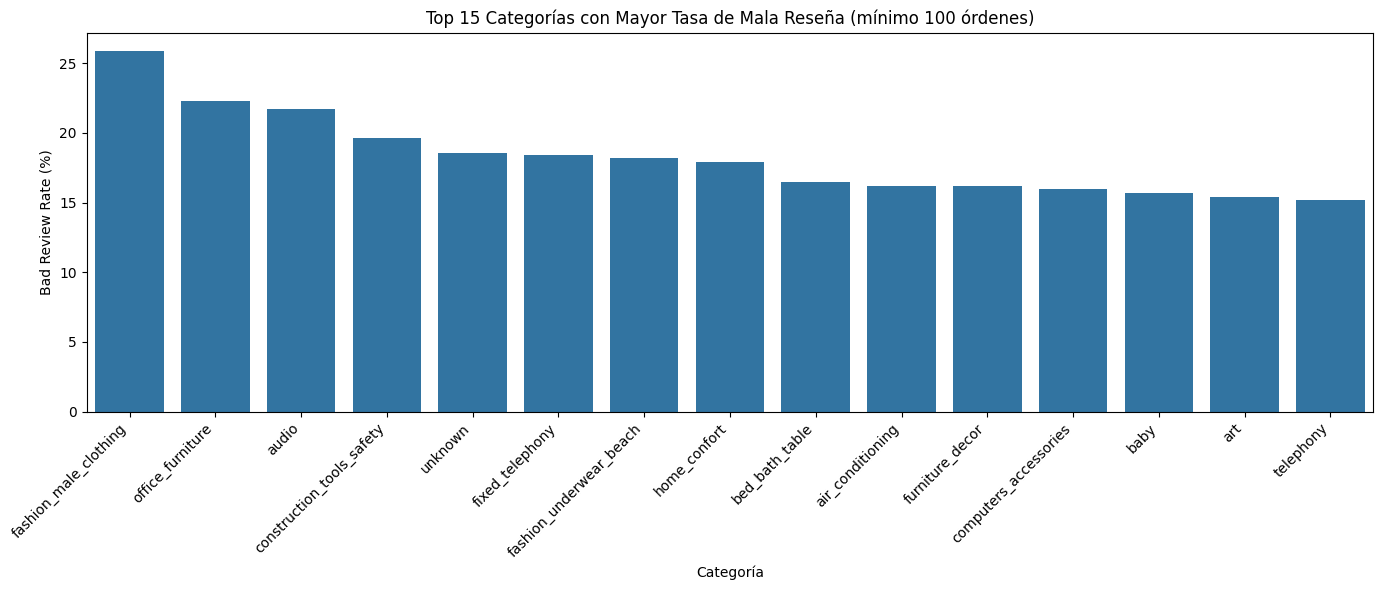


Top 15 Estados con Mayor Tasa de Mala Reseña (mínimo 100 órdenes):
customer_state  bad_review_rate  orders
            AL        23.486683     413
            SE        21.714286     350
            MA        21.686747     747
            RJ        20.417056   12852
            CE        19.685629    1336
            PA        19.282051     975
            BA        18.698225    3380
            PI        18.181818     495
            PE        16.585956    1652
            PB        16.417910     536
            RO        15.415020     253
            DF        15.000000    2140
            ES        14.756517    2033
            GO        14.702970    2020
            MS        14.545455     715


In [16]:
## 14. Análisis de satisfacción básica

# Analizar review_score_avg
# Crear distribución de review_score_avg redondeado
fact_orders['review_score_rounded'] = fact_orders['review_score_avg'].round()
review_dist = fact_orders['review_score_rounded'].value_counts().sort_index()

print("Distribución de review_score (redondeado):")
print(review_dist)

# Visualizar distribución de review_score_avg
plt.figure(figsize=(10, 6))
sns.barplot(x=review_dist.index, y=review_dist.values)
plt.title('Distribución de Review Score')
plt.xlabel('Review Score')
plt.ylabel('Cantidad de Órdenes')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'review_score_distribution.png')
plt.show()

# Guardar distribución
review_dist_df = review_dist.reset_index()
review_dist_df.columns = ['review_score', 'count']
review_dist_df.to_csv(REPORTS_DIR / 'review_score_distribution.csv', index=False)

# Promedio de review_score_avg por mes
review_by_month = fact_orders.groupby('purchase_year_month')['review_score_avg'].mean().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(review_by_month['purchase_year_month'], review_by_month['review_score_avg'], marker='o')
plt.title('Review Score Promedio Mensual')
plt.xlabel('Mes')
plt.ylabel('Review Score Promedio')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'review_score_monthly.png')
plt.show()

# Promedio de review_score_avg por order_status
review_by_status = fact_orders.groupby('order_status')['review_score_avg'].mean().reset_index()
print("\nReview Score Promedio por Estado de Orden:")
print(review_by_status.to_string(index=False))

# Bad review rate general (review < 3)
fact_orders['is_bad_review'] = fact_orders['review_score_avg'] < 3
bad_review_rate_general = fact_orders['is_bad_review'].sum() / len(fact_orders) * 100
print(f"\nBad Review Rate General: {bad_review_rate_general:.2f}%")

# Bad review rate por categoría (mínimo 100 órdenes)
bad_review_by_category = fact_orders.groupby('main_category').agg({
    'is_bad_review': 'mean',
    'order_id': 'nunique'
}).reset_index()
bad_review_by_category.columns = ['main_category', 'bad_review_rate', 'orders']
bad_review_by_category['bad_review_rate'] = bad_review_by_category['bad_review_rate'] * 100
bad_review_by_category = bad_review_by_category[bad_review_by_category['orders'] >= 100].sort_values('bad_review_rate', ascending=False)

print("\nTop 15 Categorías con Mayor Tasa de Mala Reseña (mínimo 100 órdenes):")
print(bad_review_by_category.head(15).to_string(index=False))

# Visualizar top 15 categorías con mayor tasa de mala reseña
plt.figure(figsize=(14, 6))
sns.barplot(data=bad_review_by_category.head(15), x='main_category', y='bad_review_rate')
plt.title('Top 15 Categorías con Mayor Tasa de Mala Reseña (mínimo 100 órdenes)')
plt.xlabel('Categoría')
plt.ylabel('Bad Review Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'bad_review_by_category.png')
plt.show()

# Guardar tabla
bad_review_by_category.to_csv(REPORTS_DIR / 'bad_review_by_category.csv', index=False)

# Bad review rate por estado (mínimo 100 órdenes)
bad_review_by_state = fact_orders.groupby('customer_state').agg({
    'is_bad_review': 'mean',
    'order_id': 'nunique'
}).reset_index()
bad_review_by_state.columns = ['customer_state', 'bad_review_rate', 'orders']
bad_review_by_state['bad_review_rate'] = bad_review_by_state['bad_review_rate'] * 100
bad_review_by_state = bad_review_by_state[bad_review_by_state['orders'] >= 100].sort_values('bad_review_rate', ascending=False)

print("\nTop 15 Estados con Mayor Tasa de Mala Reseña (mínimo 100 órdenes):")
print(bad_review_by_state.head(15).to_string(index=False))

# Guardar tabla
bad_review_by_state.to_csv(REPORTS_DIR / 'bad_review_by_state.csv', index=False)

In [17]:
## 15. Detección exploratoria de valores extremos básicos

# Revisar con describe y percentiles
outlier_columns = [
    'total_price',
    'total_freight',
    'payment_total',
    'freight_ratio',
    'delivery_time_days',
    'delivery_delay_days'
]

# Filtrar columnas que existen en el dataframe
existing_outlier_columns = [col for col in outlier_columns if col in fact_orders.columns]

print("Estadísticas descriptivas de variables clave:")
print(fact_orders[existing_outlier_columns].describe())

# Crear tabla de percentiles
percentiles = [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 1.0]
percentile_data = []

for col in existing_outlier_columns:
    row = {'variable': col}
    for p in percentiles:
        row[f'p{int(p*100):02d}'] = fact_orders[col].quantile(p)
    percentile_data.append(row)

outlier_percentiles = pd.DataFrame(percentile_data)

print("\nPercentiles de variables clave:")
print(outlier_percentiles.to_string(index=False))

# Guardar tabla
outlier_percentiles.to_csv(REPORTS_DIR / 'basic_outlier_percentiles.csv', index=False)

Estadísticas descriptivas de variables clave:
        total_price  total_freight  payment_total  freight_ratio  delivery_time_days  delivery_delay_days
count  98666.000000   98666.000000   99440.000000   98666.000000        96476.000000         96476.000000
mean     137.754076      22.823562     160.990267       0.308389           12.558702           -11.179120
std      210.645145      21.650909     221.951257       0.314762            9.546530            10.186113
min        0.850000       0.000000       0.000000       0.000000            0.533414          -146.016123
25%       45.900000      13.850000      62.010000       0.131864            6.766403           -16.244384
50%       86.900000      17.170000     105.290000       0.224374           10.217755           -11.948941
75%      149.900000      24.040000     176.970000       0.380191           15.720327            -6.390000
max    13440.000000    1794.960000   13664.080000      21.447059          209.628611           188.975081


## 16. Conclusiones preliminares

Basado en los análisis realizados en este notebook, se presentan las siguientes conclusiones preliminares:

**Volumen y periodo analizado:**
- El dataset contiene un total de {total_orders:,} órdenes
- El periodo analizado va desde {fact_orders['order_purchase_timestamp'].min().strftime('%Y-%m-%d')} hasta {fact_orders['order_purchase_timestamp'].max().strftime('%Y-%m-%d')}
- Se identificaron {unique_customers:,} clientes únicos

**Concentración geográfica:**
- Los estados con mayor concentración de revenue son: {', '.join(state_metrics.head(3)['customer_state'].tolist())}
- El estado de {state_metrics.iloc[0]['customer_state']} concentra el {state_metrics.iloc[0]['revenue_items']/state_metrics['revenue_items'].sum()*100:.1f}% del revenue total

**Categorías principales:**
- Las categorías con mayor revenue son: {', '.join(category_metrics.head(3)['main_category'].tolist())}
- La categoría {category_metrics.iloc[0]['main_category']} representa el {category_metrics.iloc[0]['revenue_items']/category_metrics['revenue_items'].sum()*100:.1f}% del revenue total

**Tasas de cancelación y entrega:**
- La tasa de cancelación es del {cancellation_rate:.2f}%
- La tasa de entregas tardías es del {late_delivery_rate:.2f}% (sobre órdenes entregadas)
- El {delivered_orders/total_orders*100:.1f}% de las órdenes fueron entregadas exitosamente

**Satisfacción del cliente:**
- El review score promedio es de {average_review_score:.2f} sobre 5
- La tasa de malas reseñas (review < 3) es del {bad_review_rate_general:.2f}%
- Los clientes recurrentes representan el {repeat_customer_rate:.2f}% de la base

**Precaución sobre datos incompletos:**
- Los meses de septiembre y octubre de 2018 pueden estar incompletos y deben tratarse con cuidado en cualquier análisis temporal o forecasting futuro.

**Valor económico:**
- El revenue total de productos es de R$ {total_revenue_items:,.2f}
- El valor total de flete es de R$ {total_freight:,.2f}
- El valor total pagado por clientes es de R$ {total_payment_value:,.2f}
- El Average Order Value es de R$ {average_order_value:.2f}

Estas conclusiones proporcionan una base sólida para los análisis más profundos que se realizarán en los siguientes notebooks, incluyendo segmentación RFM, forecasting y desarrollo de dashboards ejecutivos.